In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import pickle
import random
import hail as hl
import subprocess

Loading BokehJS ...

## Save the gnomAD variant data that has been pruned to just D&D gene loci

In [1]:
# load gnomAD hail table
hl.init(
    log="/tmp/hail_test.log",
    spark_conf={
        "spark.hadoop.fs.s3a.impl": "org.apache.hadoop.fs.s3a.S3AFileSystem",
        "spark.hadoop.fs.s3a.aws.credentials.provider": "org.apache.hadoop.fs.s3a.AnonymousAWSCredentialsProvider",
        "spark.hadoop.fs.s3a.endpoint": "s3.us-east-1.amazonaws.com",
    }
)
hl.default_reference("GRCh38")
hl.utils.range_table(10).show()

# load main hail table
ht = hl.read_table(
    "s3a://gnomad-public-us-east-1/release/4.1.1/ht/browser/gnomad.browser.v4.1.1.sites.ht"
)

# build ALL gene intervals at once (not in a loop)
dnd_file='/wynton/group/capra/projects/dnd_project_results/RUN_04_23_26/filtered_transcripts/filtered_exon_info.csv'
dnd = pd.read_csv(dnd_file, dtype={'chromosome_name':'str'})
dnd_genes=set(dnd.hgnc_symbol)
# create a hail literal set of dnd genes
dnd_set = hl.literal(dnd_genes)
# separate out a subset of chromosome X genes
chrX_genes = set(dnd[dnd['chromosome_name']=='X']['hgnc_symbol'].unique())

# filtering genes by locus is fast relative to filtering by gene name. get loci below
gene_spans = dnd.groupby('hgnc_symbol').agg(
    chrom=('chromosome_name', 'first'),
    start=('start_position', 'min'),
    end=('end_position', 'max')
).reset_index()
intervals = []
for r in gene_spans.itertuples():
    chrom_str = str(r.chrom)
    if not chrom_str.startswith('chr'):
        chrom_str = 'chr' + chrom_str
    intervals.append(hl.parse_locus_interval(f"{chrom_str}:{r.start}-{r.end}", reference_genome='GRCh38'))

ht_pruned = hl.filter_intervals(ht, intervals)
ht_pruned.write('/wynton/home/capra/gramey02/dnd_project/revisions/hail_tables/gnomad_dnd_pruned.ht', overwrite=True)

In [13]:
# Once the array job to get the number and type of het LOF mutation per gene occurs, combine using this code
import glob

input_dir = '/wynton/home/capra/gramey02/dnd_project/revisions/results/per_gene'
output_file = '/wynton/home/capra/gramey02/dnd_project/revisions/results/dnd_lof_het_counts.csv'

files = glob.glob(os.path.join(input_dir, '*.csv'))
print(f"Found {len(files)} per-gene files.")

dfs = [pd.read_csv(f, index_col='gene_symbol') for f in files]
final_df = pd.concat(dfs)

final_df.to_csv(output_file)
print(f"Wrote combined output to {output_file}, shape={final_df.shape}")

Found 593 per-gene files.
Wrote combined output to /wynton/home/capra/gramey02/dnd_project/revisions/results/dnd_lof_het_counts.csv, shape=(593, 8)


## Create hail tables for background sets of genes

### First background set: dominant ClinGen genes (minus dnd genes)

In [4]:
dnd_file='/wynton/group/capra/projects/dnd_project_results/RUN_04_23_26/filtered_transcripts/filtered_exon_info.csv'
dnd = pd.read_csv(dnd_file, dtype={'chromosome_name':'str'})
dnd_genes=set(dnd.hgnc_symbol)

In [5]:
# load clingen gene-disease data
gd_fp = "/wynton/home/capra/gramey02/ds_context_project/data/clingen/Clingen-Gene-Disease-Summary-2025-11-13.csv"
gd = pd.read_csv(gd_fp)
cols = gd.iloc[3].values
gd = gd[5:]
gd.columns = cols
gd = gd[gd['CLASSIFICATION'].isin(['Definitive', 'Strong', 'Moderate'])]
gd=gd[gd['MOI'].isin(['AD','SD'])]
# remove the dnd genes
gd=gd[~gd['GENE SYMBOL'].isin(dnd_genes)]
dom_genes = gd[['GENE SYMBOL']].drop_duplicates()

# save the gene set
dom_genes.to_csv('/wynton/home/capra/gramey02/dnd_project/revisions/benign_lof_background_genes/dominant_minus_dnd.csv', index=False)

# run the following code through R to query ensembl for start/end information

# library(biomaRt)
# library(dplyr)
# Sys.setenv(BIOMART_CACHE = "/wynton/home/capra/gramey02/.cache/biomaRt")
# dir.create("/wynton/home/capra/gramey02/.cache/biomaRt", recursive = TRUE, showWarnings = FALSE)
# ensembl<-useEnsembl(biomart="ensembl", dataset="hsapiens_gene_ensembl", mirror='www')
# df<-read.csv('/wynton/home/capra/gramey02/dnd_project/revisions/benign_lof_background_genes/dominant_minus_dnd.csv')         
# res1<-getBM(attributes=c('hgnc_symbol','ensembl_gene_id','ensembl_transcript_id','chromosome_name','start_position','end_position','strand', 'transcript_start', 'transcript_end','transcription_start_site','transcript_length','transcript_is_canonical','transcript_tsl','gene_biotype','transcript_biotype','ensembl_peptide_id'),filters = 'hgnc_symbol',values=df$GENE.SYMBOL,mart=ensembl)
# write.csv(res1, 'output_file.csv', row.names = FALSE)

### Second background set: recessive ClinGen genes (minus dnd genes)

In [6]:
gd_fp = "/wynton/home/capra/gramey02/ds_context_project/data/clingen/Clingen-Gene-Disease-Summary-2025-11-13.csv"
gd = pd.read_csv(gd_fp)
cols = gd.iloc[3].values
gd = gd[5:]
gd.columns = cols
gd = gd[gd['CLASSIFICATION'].isin(['Definitive', 'Strong'])]
gd=gd[gd['MOI'].isin(['AR'])]
# remove the dnd genes
gd=gd[~gd['GENE SYMBOL'].isin(dnd_genes)]
recessive_genes = gd[['GENE SYMBOL']].drop_duplicates()

# save the gene set
recessive_genes.to_csv('/wynton/home/capra/gramey02/dnd_project/revisions/benign_lof_background_genes/recessive_minus_dnd.csv',index=False)

# do the same as earlier, run through R to get ensembl start/end information

## Now that we've gathered the background gene sets, let's filter the hail tables accordingly

In [12]:
# load gnomAD hail table
hl.init(
    log="/tmp/hail_test.log",
    spark_conf={
        "spark.hadoop.fs.s3a.impl": "org.apache.hadoop.fs.s3a.S3AFileSystem",
        "spark.hadoop.fs.s3a.aws.credentials.provider": "org.apache.hadoop.fs.s3a.AnonymousAWSCredentialsProvider",
        "spark.hadoop.fs.s3a.endpoint": "s3.us-east-1.amazonaws.com",
    }
)
hl.default_reference("GRCh38")
hl.utils.range_table(10).show()

# load main hail table
ht = hl.read_table(
    "s3a://gnomad-public-us-east-1/release/4.1.1/ht/browser/gnomad.browser.v4.1.1.sites.ht"
)

# load background gene set
gene_file = '/wynton/home/capra/gramey02/dnd_project/revisions/benign_lof_background_genes/dom_genes_ensembl_mapped.csv'
genes = pd.read_csv(gene_file, dtype={'chromosome_name': 'str'})
background_genes = set(genes.hgnc_symbol)

# create a hail literal set of background genes
background_set = hl.literal(background_genes)

# --- filter to valid primary-assembly contigs BEFORE aggregating gene spans ---
valid_contigs = {f'chr{i}' for i in range(1, 23)} | {'chrX'}

genes['chrom_fixed'] = genes['chromosome_name'].apply(
    lambda c: c if str(c).startswith('chr') else f'chr{c}'
)

bad_rows = genes[~genes['chrom_fixed'].isin(valid_contigs)]
if len(bad_rows) > 0:
    print(f"Dropping {len(bad_rows)} rows on non-primary contigs, affecting {bad_rows['hgnc_symbol'].nunique()} genes")
    print(bad_rows[['hgnc_symbol', 'chrom_fixed']].drop_duplicates())

genes = genes[genes['chrom_fixed'].isin(valid_contigs)].reset_index(drop=True)

# separate out a subset of chromosome X genes (from cleaned genes)
chrX_genes = set(genes[genes['chrom_fixed'] == 'chrX']['hgnc_symbol'].unique())

# now aggregate gene spans — every remaining row is guaranteed on a primary contig,
# so min/max start/end can't mix coordinate systems across contigs
gene_spans = genes.groupby('hgnc_symbol').agg(
    chrom=('chrom_fixed', 'first'),
    start=('start_position', 'min'),
    end=('end_position', 'max')
).reset_index()

# build all gene intervals at once
intervals = []
for r in gene_spans.itertuples():
    intervals.append(hl.parse_locus_interval(f"{r.chrom}:{r.start}-{r.end}", reference_genome='GRCh38'))

ht_pruned = hl.filter_intervals(ht, intervals)
ht_pruned.write('/wynton/home/capra/gramey02/dnd_project/revisions/hail_tables/gnomad_dom_minus_dnd_pruned.ht', overwrite=True)
hl.stop()

2026-07-31 12:56:30.005 WARN  NativeCodeLoader:60 - Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


2026-07-31 12:56:31.029 WARN  SparkConf:72 - Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in mesos/standalone/kubernetes and LOCAL_DIRS in YARN).
2026-07-31 12:56:31.915 WARN  Utils:72 - Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Running on Apache Spark version 3.5.8
SparkUI available at http://gpudev1.wynton.ucsf.edu:4041
2026-07-31 12:56:32.656 SparkBackend$: WARN: This Hail JAR was compiled for Spark 3.5.3, running with Spark 3.5.8.
  Compatibility is not guaranteed.
Welcome to
     __  __     <>__
    / /_/ /__  __/ /
   / __  / _ `/ / /
  /_/ /_/\_,_/_/_/   version 0.2.138-58956ebc28fc
LOGGING: writing to /tmp/hail_test.log


""
idx
int32
0
1
2
3
4
5
6
7


2026-07-31 12:56:37.115 MetricsConfig: WARN: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties


Dropping 168 rows on non-primary contigs, affecting 17 genes
     hgnc_symbol              chrom_fixed
0         SHANK3   chrHG1311_HG2539_PATCH
1         POLR2A          chrHG2046_PATCH
3           PTEN          chrHG2334_PATCH
16         KAT6B          chrHG2191_PATCH
57        COL3A1          chrHG2494_PATCH
62          APOB   chrHG2231_HG2496_PATCH
66         GATA4            chrHG76_PATCH
74         KCNQ1        chrHSCHR11_1_CTG7
98        KANSL1        chrHSCHR17_1_CTG5
183        HNF1B        chrHSCHR17_7_CTG4
209       KANSL1        chrHSCHR17_2_CTG5
246      GATAD2B        chrHSCHR1_1_CTG31
401        KCNQ2        chrHSCHR20_1_CTG4
456        TCF20        chrHSCHR22_1_CTG1
460      SMARCB1        chrHSCHR22_1_CTG7
467        TCF20        chrHSCHR22_3_CTG1
471        KIF5C       chrHSCHR2_2_CTG7_2
561         DLL1         chrHSCHR6_1_CTG5
1107     SYNGAP1  chrHSCHR6_MHC_SSTO_CTG1


In [15]:
# load background gene set
gene_file = '/wynton/home/capra/gramey02/dnd_project/revisions/benign_lof_background_genes/dom_genes_ensembl_mapped.csv'
genes = pd.read_csv(gene_file, dtype={'chromosome_name': 'str'})
background_genes = set(genes.hgnc_symbol)

# create a hail literal set of background genes
background_set = hl.literal(background_genes)

# --- filter to valid primary-assembly contigs BEFORE aggregating gene spans ---
valid_contigs = {f'chr{i}' for i in range(1, 23)} | {'chrX'}

genes['chrom_fixed'] = genes['chromosome_name'].apply(
    lambda c: c if str(c).startswith('chr') else f'chr{c}'
)

bad_rows = genes[~genes['chrom_fixed'].isin(valid_contigs)]
if len(bad_rows) > 0:
    print(f"Dropping {len(bad_rows)} rows on non-primary contigs, affecting {bad_rows['hgnc_symbol'].nunique()} genes")
    print(bad_rows[['hgnc_symbol', 'chrom_fixed']].drop_duplicates())

genes = genes[genes['chrom_fixed'].isin(valid_contigs)].reset_index(drop=True)
print(len(genes.hgnc_symbol.unique()))

Dropping 168 rows on non-primary contigs, affecting 17 genes
     hgnc_symbol              chrom_fixed
0         SHANK3   chrHG1311_HG2539_PATCH
1         POLR2A          chrHG2046_PATCH
3           PTEN          chrHG2334_PATCH
16         KAT6B          chrHG2191_PATCH
57        COL3A1          chrHG2494_PATCH
62          APOB   chrHG2231_HG2496_PATCH
66         GATA4            chrHG76_PATCH
74         KCNQ1        chrHSCHR11_1_CTG7
98        KANSL1        chrHSCHR17_1_CTG5
183        HNF1B        chrHSCHR17_7_CTG4
209       KANSL1        chrHSCHR17_2_CTG5
246      GATAD2B        chrHSCHR1_1_CTG31
401        KCNQ2        chrHSCHR20_1_CTG4
456        TCF20        chrHSCHR22_1_CTG1
460      SMARCB1        chrHSCHR22_1_CTG7
467        TCF20        chrHSCHR22_3_CTG1
471        KIF5C       chrHSCHR2_2_CTG7_2
561         DLL1         chrHSCHR6_1_CTG5
1107     SYNGAP1  chrHSCHR6_MHC_SSTO_CTG1
262


In [ ]:
# combine resulting files
import glob

input_dir = '/wynton/home/capra/gramey02/dnd_project/revisions/results/dom_minus_dnd/per_gene'
output_file = '/wynton/home/capra/gramey02/dnd_project/revisions/results/dom_minus_dnd/dnd_lof_het_counts.csv'

files = glob.glob(os.path.join(input_dir, '*.csv'))
print(f"Found {len(files)} per-gene files.")

dfs = [pd.read_csv(f, index_col='gene_symbol') for f in files]
final_df = pd.concat(dfs)

final_df.to_csv(output_file)
print(f"Wrote combined output to {output_file}, shape={final_df.shape}")

In [14]:
# load gnomAD hail table
hl.init(
    log="/tmp/hail_test.log",
    spark_conf={
        "spark.hadoop.fs.s3a.impl": "org.apache.hadoop.fs.s3a.S3AFileSystem",
        "spark.hadoop.fs.s3a.aws.credentials.provider": "org.apache.hadoop.fs.s3a.AnonymousAWSCredentialsProvider",
        "spark.hadoop.fs.s3a.endpoint": "s3.us-east-1.amazonaws.com",
    }
)
hl.default_reference("GRCh38")
hl.utils.range_table(10).show()

# load main hail table
ht = hl.read_table(
    "s3a://gnomad-public-us-east-1/release/4.1.1/ht/browser/gnomad.browser.v4.1.1.sites.ht"
)

# load background gene set
gene_file = '/wynton/home/capra/gramey02/dnd_project/revisions/benign_lof_background_genes/recessive_genes_ensembl_mapped.csv'
genes = pd.read_csv(gene_file, dtype={'chromosome_name': 'str'})
background_genes = set(genes.hgnc_symbol)

# create a hail literal set of background genes
background_set = hl.literal(background_genes)

# --- filter to valid primary-assembly contigs BEFORE aggregating gene spans ---
valid_contigs = {f'chr{i}' for i in range(1, 23)} | {'chrX', 'chrY', 'chrM'}

genes['chrom_fixed'] = genes['chromosome_name'].apply(
    lambda c: c if str(c).startswith('chr') else f'chr{c}'
)

bad_rows = genes[~genes['chrom_fixed'].isin(valid_contigs)]
if len(bad_rows) > 0:
    print(f"Dropping {len(bad_rows)} rows on non-primary contigs, affecting {bad_rows['hgnc_symbol'].nunique()} genes")
    print(bad_rows[['hgnc_symbol', 'chrom_fixed']].drop_duplicates())

genes = genes[genes['chrom_fixed'].isin(valid_contigs)].reset_index(drop=True)

# separate out a subset of chromosome X genes (from cleaned genes)
chrX_genes = set(genes[genes['chrom_fixed'] == 'chrX']['hgnc_symbol'].unique())

# now aggregate gene spans — every remaining row is guaranteed on a primary contig,
# so min/max start/end can't mix coordinate systems across contigs
gene_spans = genes.groupby('hgnc_symbol').agg(
    chrom=('chrom_fixed', 'first'),
    start=('start_position', 'min'),
    end=('end_position', 'max')
).reset_index()

# build all gene intervals at once
intervals = []
for r in gene_spans.itertuples():
    intervals.append(hl.parse_locus_interval(f"{r.chrom}:{r.start}-{r.end}", reference_genome='GRCh38'))

ht_pruned = hl.filter_intervals(ht, intervals)
ht_pruned.write('/wynton/home/capra/gramey02/dnd_project/revisions/hail_tables/gnomad_recessive_minus_dnd_pruned.ht', overwrite=True)
hl.stop()

2026-07-31 13:03:31.914 WARN  NativeCodeLoader:60 - Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


2026-07-31 13:03:33.235 WARN  SparkConf:72 - Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in mesos/standalone/kubernetes and LOCAL_DIRS in YARN).
2026-07-31 13:03:34.223 WARN  Utils:72 - Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Running on Apache Spark version 3.5.8
SparkUI available at http://gpudev1.wynton.ucsf.edu:4041
2026-07-31 13:03:35.016 SparkBackend$: WARN: This Hail JAR was compiled for Spark 3.5.3, running with Spark 3.5.8.
  Compatibility is not guaranteed.
Welcome to
     __  __     <>__
    / /_/ /__  __/ /
   / __  / _ `/ / /
  /_/ /_/\_,_/_/_/   version 0.2.138-58956ebc28fc
LOGGING: writing to /tmp/hail_test.log


""
idx
int32
0
1
2
3
4
5
6
7


2026-07-31 13:03:39.825 MetricsConfig: WARN: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties


Dropping 776 rows on non-primary contigs, affecting 49 genes
     hgnc_symbol              chrom_fixed
0           GRK1          chrHG1524_PATCH
3           HMX1          chrHG1298_PATCH
5           PEX5          chrHG1398_PATCH
66         SURF1          chrHG2030_PATCH
71      ADAMTS13          chrHG2030_PATCH
...          ...                      ...
5344       VARS1   chrHSCHR6_MHC_QBL_CTG1
5348       SKIC2   chrHSCHR6_MHC_MCF_CTG1
5363       SKIC2  chrHSCHR6_MHC_SSTO_CTG1
5546        TAP1   chrHSCHR6_MHC_QBL_CTG1
5577      MPIG6B   chrHSCHR6_MHC_QBL_CTG1

[103 rows x 2 columns]


2026-07-31 13:03:58.725 DAGScheduler: WARN: Broadcasting large task binary with size 1270.0 KiB
2026-07-31 13:03:58.758 TaskSetManager: WARN: Stage 3 contains a task of very large size (1277 KiB). The maximum recommended task size is 1000 KiB.
                                                                                

In [16]:
# load background gene set
gene_file = '/wynton/home/capra/gramey02/dnd_project/revisions/benign_lof_background_genes/recessive_genes_ensembl_mapped.csv'
genes = pd.read_csv(gene_file, dtype={'chromosome_name': 'str'})
background_genes = set(genes.hgnc_symbol)

# create a hail literal set of background genes
background_set = hl.literal(background_genes)

# --- filter to valid primary-assembly contigs BEFORE aggregating gene spans ---
valid_contigs = {f'chr{i}' for i in range(1, 23)} | {'chrX', 'chrY', 'chrM'}

genes['chrom_fixed'] = genes['chromosome_name'].apply(
    lambda c: c if str(c).startswith('chr') else f'chr{c}'
)

bad_rows = genes[~genes['chrom_fixed'].isin(valid_contigs)]
if len(bad_rows) > 0:
    print(f"Dropping {len(bad_rows)} rows on non-primary contigs, affecting {bad_rows['hgnc_symbol'].nunique()} genes")
    print(bad_rows[['hgnc_symbol', 'chrom_fixed']].drop_duplicates())

genes = genes[genes['chrom_fixed'].isin(valid_contigs)].reset_index(drop=True)
print(len(genes.hgnc_symbol.unique()))

Dropping 776 rows on non-primary contigs, affecting 49 genes
     hgnc_symbol              chrom_fixed
0           GRK1          chrHG1524_PATCH
3           HMX1          chrHG1298_PATCH
5           PEX5          chrHG1398_PATCH
66         SURF1          chrHG2030_PATCH
71      ADAMTS13          chrHG2030_PATCH
...          ...                      ...
5344       VARS1   chrHSCHR6_MHC_QBL_CTG1
5348       SKIC2   chrHSCHR6_MHC_MCF_CTG1
5363       SKIC2  chrHSCHR6_MHC_SSTO_CTG1
5546        TAP1   chrHSCHR6_MHC_QBL_CTG1
5577      MPIG6B   chrHSCHR6_MHC_QBL_CTG1

[103 rows x 2 columns]
1055


In [18]:
# let's combine the resulting files
import glob

input_dir = '/wynton/home/capra/gramey02/dnd_project/revisions/results/recessive_minus_dnd/per_gene'
output_file = '/wynton/home/capra/gramey02/dnd_project/revisions/results/recessive_minus_dnd/recessive_minus_dnd_lof_het_counts.csv'

files = glob.glob(os.path.join(input_dir, '*.csv'))
print(f"Found {len(files)} per-gene files.")

dfs = [pd.read_csv(f, index_col='gene_symbol') for f in files]
final_df = pd.concat(dfs)

final_df.to_csv(output_file)
print(f"Wrote combined output to {output_file}, shape={final_df.shape}")

Found 1007 per-gene files.
Wrote combined output to /wynton/home/capra/gramey02/dnd_project/revisions/results/recessive_minus_dnd/recessive_minus_dnd_lof_het_counts.csv, shape=(1007, 8)


## Now, load the results, and compare the distributions to each other

In [3]:
dnd = pd.read_csv('/wynton/home/capra/gramey02/dnd_project/revisions/results/dnd_genes/dnd_lof_het_counts.csv')
dom = pd.read_csv('/wynton/home/capra/gramey02/dnd_project/revisions/results/dom_minus_dnd/dom_minus_dnd_lof_het_counts.csv')
recessive = pd.read_csv('/wynton/home/capra/gramey02/dnd_project/revisions/results/recessive_minus_dnd/recessive_minus_dnd_lof_het_counts.csv')

In [4]:
dnd

,gene_symbol,pathogenic,likely_pathogenic,uncertain_significance,likely_benign,benign,association,not_provided,other_or_unclassified
0,IKZF3,0,0,0,0,0,0,0,31
1,TARDBP,0,0,1,0,0,0,0,12
2,ACD,3,1,15,1,0,0,0,77
3,SLC1A3,0,0,1,1,0,0,0,50
4,KCNJ11,1,1,1,0,0,0,0,13
...,...,...,...,...,...,...,...,...,...
588,DNM2,0,0,3,0,0,0,0,53
589,HEPACAM,3,1,0,0,0,0,0,30
590,ATL1,3,0,2,0,0,0,0,62
591,SPTBN2,3,2,1,0,0,0,0,217


In [5]:
## Let's specifically take a look at the high-confidence, heterozgyous benign/likely benign variants
dnd_benign = dnd.benign.values + dnd.likely_benign.values
dom_benign = dom.benign.values + dom.likely_benign.values
recessive_benign = recessive.benign.values + recessive.likely_benign.values

In [6]:
import matplotlib.pyplot as plt

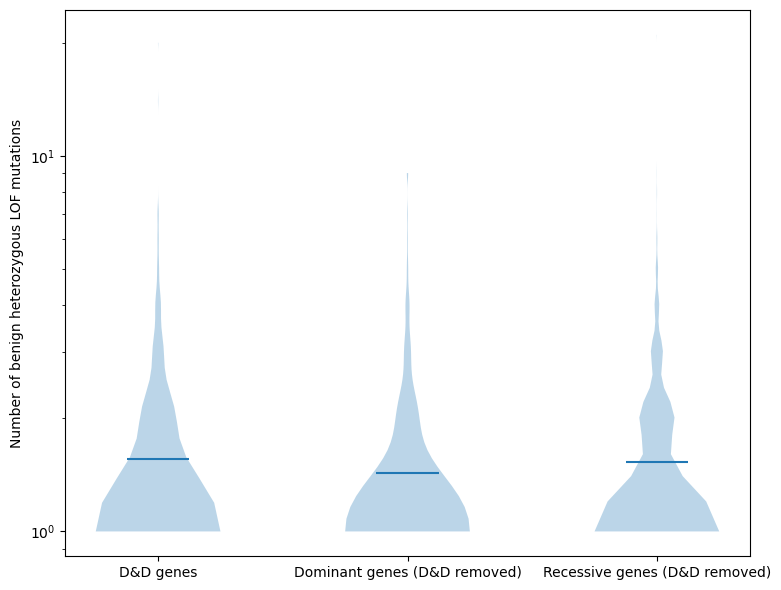

In [7]:
# plot as a violin plot
fig, ax = plt.subplots(figsize=(8, 6))

datasets=[dnd_benign+1, dom_benign+1, recessive_benign+1]
positions = [1, 2, 3]
parts = ax.violinplot(datasets, positions=positions,
                       showmeans=True, showmedians=False,
                       showextrema=False)

# # Draw Q1 - 1.5*IQR and Q3 + 1.5*IQR fences for each violin
# line_half_width = 0.25  # controls how wide the drawn lines are

# for pos, data in zip(positions, datasets):
#     data = np.array(data)
#     q1, q3 = np.percentile(data, [25, 75])
#     iqr = q3 - q1

#     lower_fence = q1 - 1.5 * iqr
#     upper_fence = q3 + 1.5 * iqr

#     ax.hlines([lower_fence, upper_fence], pos - line_half_width, pos + line_half_width,
#               colors='black', linestyles='-', linewidth=1.5, zorder=3)

ax.set_xticks(positions)
ax.set_xticklabels(['D&D genes', 'Dominant genes (D&D removed)', 'Recessive genes (D&D removed)'])
ax.set_ylabel('Number of benign heterozygous LOF mutations')
plt.yscale('log')
plt.tight_layout()
plt.show()

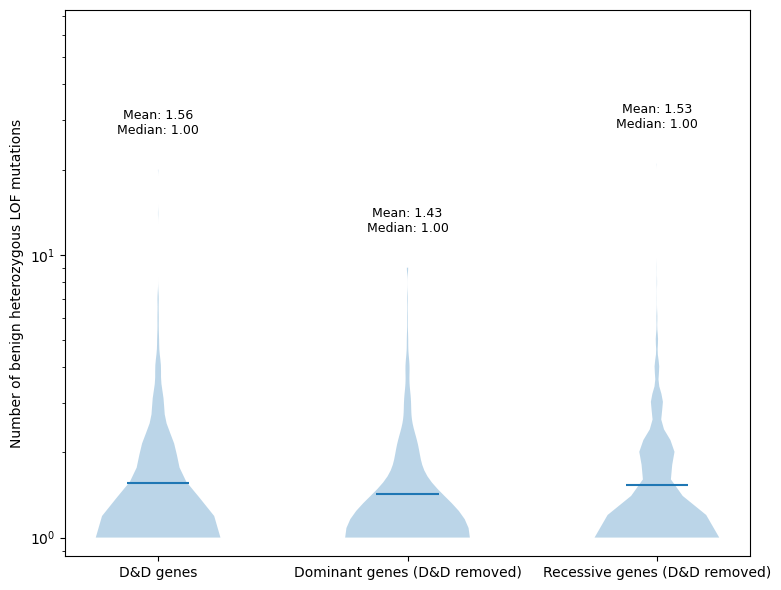

In [8]:
import numpy as np

# plot as a violin plot
fig, ax = plt.subplots(figsize=(8, 6))
datasets = [dnd_benign+1, dom_benign+1, recessive_benign+1]
positions = [1, 2, 3]
parts = ax.violinplot(datasets, positions=positions,
                       showmeans=True, showmedians=False,
                       showextrema=False)

ax.set_xticks(positions)
ax.set_xticklabels(['D&D genes', 'Dominant genes (D&D removed)', 'Recessive genes (D&D removed)'])
ax.set_ylabel('Number of benign heterozygous LOF mutations')
plt.yscale('log')

# Annotate mean and median above each violin
for pos, data in zip(positions, datasets):
    data = np.array(data)
    mean_val = np.mean(data)
    median_val = np.median(data)

    # Place label just above the max value of this dataset (multiplicative offset for log scale)
    text_y = data.max() * 1.3

    ax.text(pos, text_y, f'Mean: {mean_val:.2f}\nMedian: {median_val:.2f}',
            ha='center', va='bottom', fontsize=9)

# Give some headroom above the highest label so nothing gets clipped
ax.set_ylim(top=ax.get_ylim()[1] * 3)

plt.tight_layout()
plt.show()

In [9]:
# let's compare the distributions with mann whitney u
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    dom_benign,
    dnd_benign,
    alternative='less'
)

print(f"U statistic: {stat}")
print(f"p-value: {p}")

U statistic: 67203.0
p-value: 0.011123457513206867


In [10]:
stat, p = mannwhitneyu(
    recessive_benign,
    dnd_benign,
    alternative='two-sided'
)

print(f"U statistic: {stat}")
print(f"p-value: {p}")

U statistic: 300441.0
p-value: 0.7967373955273269


In [11]:
stat, p = mannwhitneyu(
    recessive_benign,
    dom_benign,
    alternative='two-sided'
)

print(f"U statistic: {stat}")
print(f"p-value: {p}")

U statistic: 134449.0
p-value: 0.0091739630039063


In [15]:
# I feel like if it's annotated as benign, it is less likely to be annotated as LOF, so there's a bias here

In [ ]:
# Let's instead look at pathogenic varaints